# Final Task: Credit Risk Prediction
**ID/X Partners x Rakamin Academy - Virtual Internship Experience (Data Scientist)**

Nama: Allan Glory Krisrodemar
NRP: 3124510118

Dataset yang dipakai: `loan_data_2007_2014.csv` (LendingClub), 466.285 baris dan 74 kolom.

Tujuan dari project ini adalah membangun model klasifikasi untuk memprediksi risiko kredit peminjam, yaitu memprediksi apakah suatu pinjaman berpotensi gagal bayar (bad loan) atau tidak (good loan), berdasarkan data historis peminjam.

## 1. Data Understanding

Tahap ini saya lakukan untuk mengenal struktur dataset terlebih dahulu: jumlah baris/kolom, tipe data tiap kolom, persentase missing value, serta distribusi kolom `loan_status` yang nantinya jadi dasar penentuan target.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/Final Task IDX/loan_data_2007_2014.csv', index_col=0, low_memory=False)

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (466285, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# cek tipe data tiap kolom
print("Tipe data:")
print(df.dtypes.value_counts())

# cek persentase kolom yang kosong
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print("\nJumlah kolom yang 100% kosong:", (missing_pct == 100).sum())
print("Jumlah kolom yang >50% kosong:", (missing_pct > 50).sum())

# lihat distribusi status pinjaman
print("\nDistribusi loan_status:")
print(df['loan_status'].value_counts())

# cek data duplikat
print("\nJumlah baris duplikat:", df.duplicated().sum())

Tipe data:
float64    46
object     22
int64       6
Name: count, dtype: int64

Jumlah kolom yang 100% kosong: 17
Jumlah kolom yang >50% kosong: 21

Distribusi loan_status:
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Jumlah baris duplikat: 0


In [5]:
bad_status = [
    'Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
    'In Grace Period', 'Does not meet the credit policy. Status:Charged Off'
]

df['risk_label'] = np.where(df['loan_status'].isin(bad_status), 1, 0)  # 1 = bad loan, 0 = good loan

print(df['risk_label'].value_counts())
print((df['risk_label'].value_counts(normalize=True) * 100).round(2), "(%)")

risk_label
0    410953
1     55332
Name: count, dtype: int64
risk_label
0    88.13
1    11.87
Name: proportion, dtype: float64 (%)


## 2. Exploratory Data Analysis (EDA)

Sebelum masuk ke EDA, saya buat dulu label target `risk_label` dari kolom `loan_status`, di mana status seperti `Charged Off`, `Default`, dan `Late` saya kelompokkan sebagai bad loan (1), sisanya good loan (0).

Selanjutnya saya eksplorasi:
- Distribusi target (good vs bad loan)
- Bad loan rate berdasarkan kategori (grade, term, home ownership, purpose)
- Hubungan interest rate dengan risiko
- Korelasi antar fitur numerik

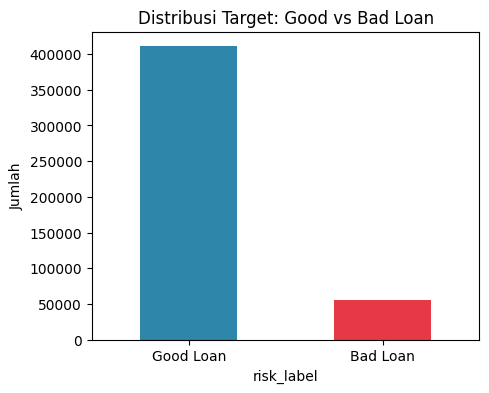

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
df['risk_label'].map({0:'Good Loan', 1:'Bad Loan'}).value_counts().plot(kind='bar', color=['#2E86AB','#E63946'])
plt.title('Distribusi Target: Good vs Bad Loan')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

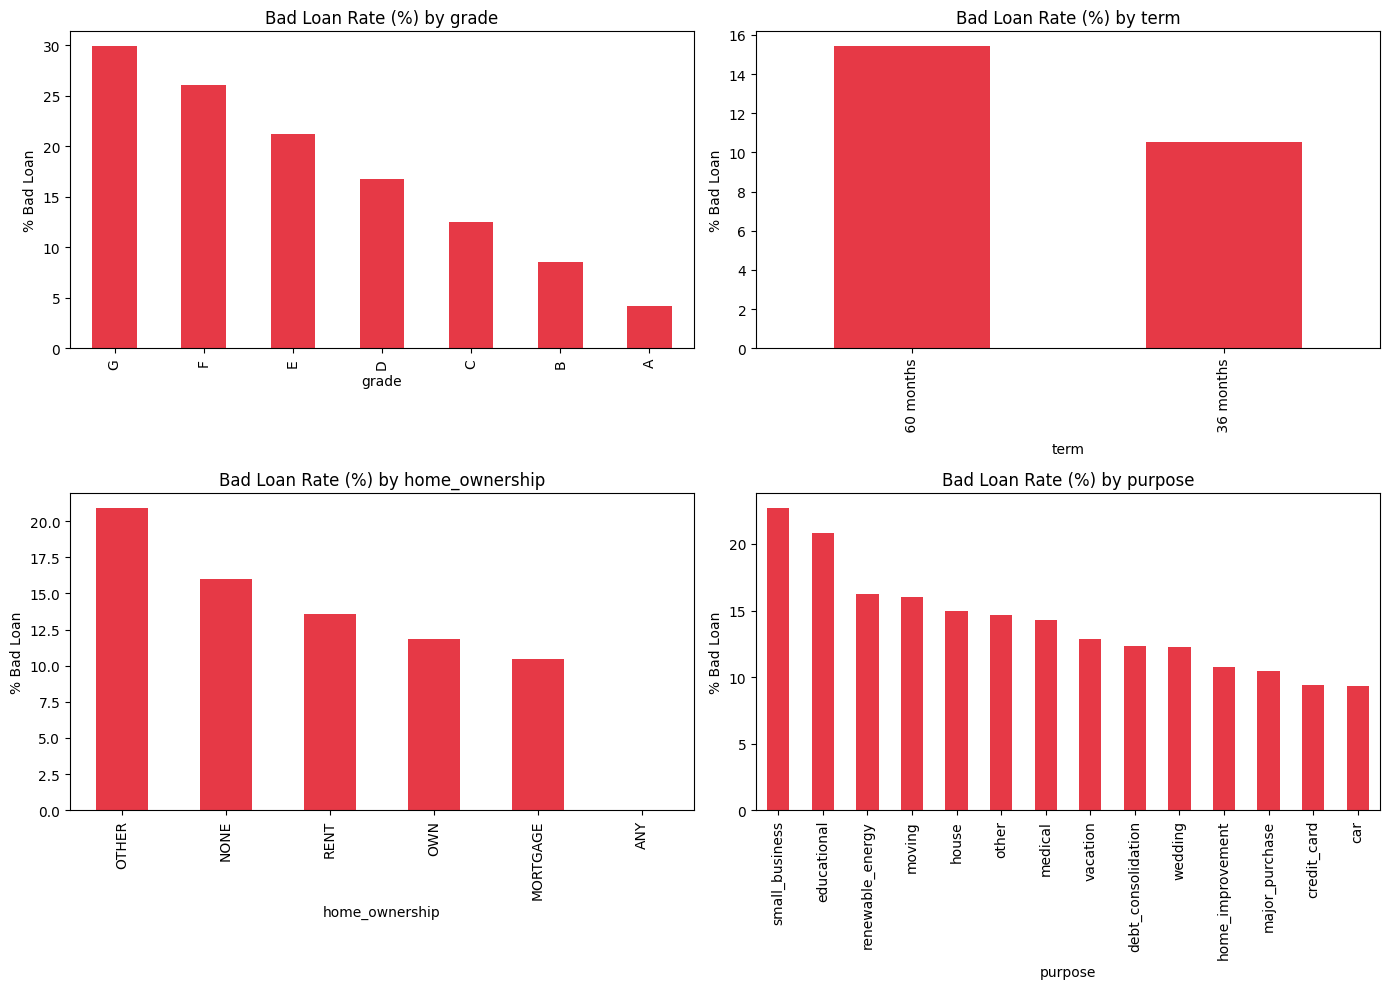

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['grade', 'term', 'home_ownership', 'purpose']):
    rate = df.groupby(col)['risk_label'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#E63946')
    ax.set_title(f'Bad Loan Rate (%) by {col}')
    ax.set_ylabel('% Bad Loan')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

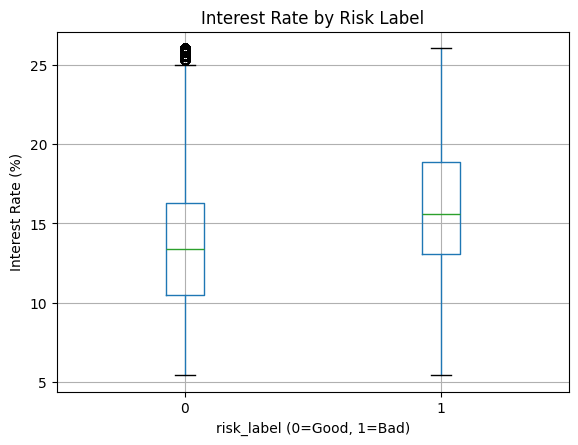

In [8]:
plt.figure(figsize=(6,4))
df.boxplot(column='int_rate', by='risk_label')
plt.title('Interest Rate by Risk Label')
plt.suptitle('')
plt.xlabel('risk_label (0=Good, 1=Bad)')
plt.ylabel('Interest Rate (%)')
plt.show()

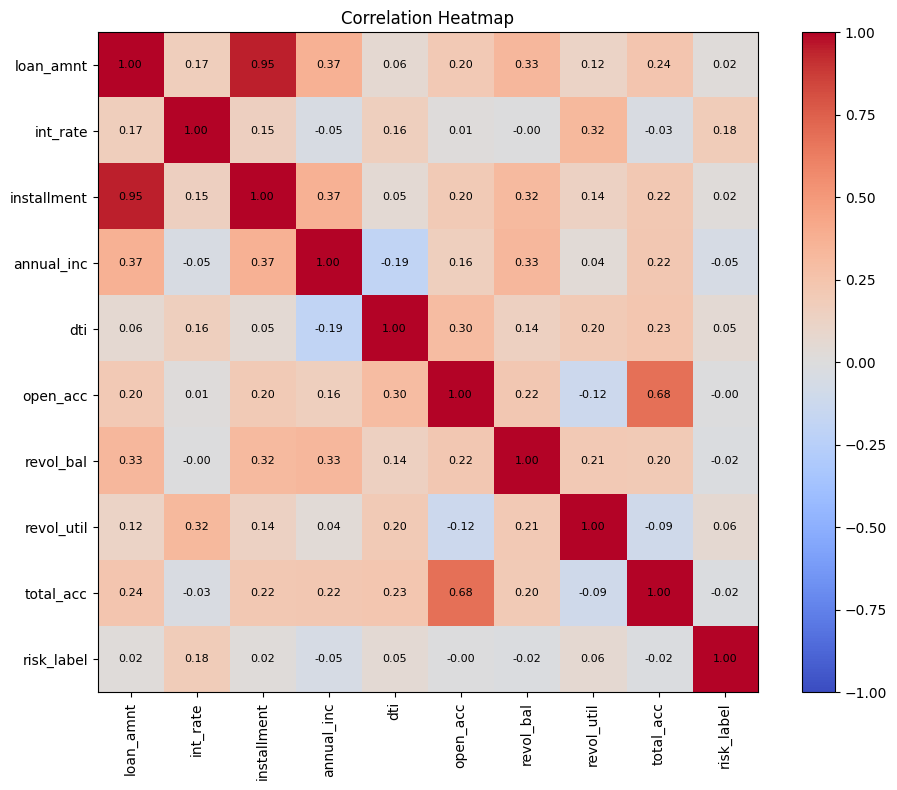

In [9]:
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'risk_label']

plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il

## 3. Data Preparation

Di tahap ini saya:
1. Membuang kolom yang tidak relevan (ID, teks bebas) dan kolom yang menyebabkan **data leakage** — yaitu kolom yang isinya baru terisi setelah pinjaman berjalan/selesai (misalnya `total_pymnt`, `recoveries`), karena info ini belum tersedia saat prediksi seharusnya dilakukan (sebelum pinjaman disetujui).
2. Feature engineering: `term` dan `emp_length` diubah ke angka, serta membuat fitur baru `credit_history_months` dan `has_delinq_history`.
3. Menangani missing value dengan median imputation.
4. One-hot encoding untuk kolom kategorikal.
5. Split data train/test (80:20, stratified) dan scaling (StandardScaler).

In [11]:
cols_to_drop = [
    # Grup 1: ID/teks
    'id', 'member_id', 'url', 'desc', 'title', 'emp_title', 'zip_code', 'policy_code',
    # Grup 2: data leakage
    'funded_amnt', 'funded_amnt_inv', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    # Grup 3: mayoritas kosong + loan_status asli
    'loan_status', 'mths_since_last_record', 'mths_since_last_major_derog',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
    'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m'
]

df_model = df.drop(columns=cols_to_drop)
print("Kolom tersisa:", df_model.shape[1])
print(df_model.columns.tolist())

Kolom tersisa: 32
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'risk_label']


In [12]:
print(df_model[['term', 'emp_length', 'earliest_cr_line', 'issue_d']].head(10))

         term emp_length earliest_cr_line issue_d
0   36 months  10+ years           Jan-85  Dec-11
1   60 months   < 1 year           Apr-99  Dec-11
2   36 months  10+ years           Nov-01  Dec-11
3   36 months  10+ years           Feb-96  Dec-11
4   60 months     1 year           Jan-96  Dec-11
5   36 months    3 years           Nov-04  Dec-11
6   60 months    8 years           Jul-05  Dec-11
7   36 months    9 years           Jan-07  Dec-11
8   60 months    4 years           Apr-04  Dec-11
9   60 months   < 1 year           Sep-04  Dec-11


In [13]:
# 1. term: ambil angkanya aja
df_model['term'] = df_model['term'].str.extract(r'(\d+)').astype(int)

# 2. emp_length: mapping manual ke angka
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_length_map)

# 3. earliest_cr_line & issue_d: ubah ke datetime, lalu hitung selisih bulan
df_model['earliest_cr_line'] = pd.to_datetime(df_model['earliest_cr_line'], format='%b-%y', errors='coerce')
df_model['issue_d'] = pd.to_datetime(df_model['issue_d'], format='%b-%y', errors='coerce')

df_model['credit_history_months'] = (
    (df_model['issue_d'].dt.year - df_model['earliest_cr_line'].dt.year) * 12 +
    (df_model['issue_d'].dt.month - df_model['earliest_cr_line'].dt.month)
)

# cek hasilnya
print(df_model[['term', 'emp_length', 'credit_history_months']].head(10))
print("\nMissing emp_length:", df_model['emp_length'].isna().sum())
print("Missing credit_history_months:", df_model['credit_history_months'].isna().sum())

   term  emp_length  credit_history_months
0    36        10.0                  323.0
1    60         0.0                  152.0
2    36        10.0                  121.0
3    36        10.0                  190.0
4    60         1.0                  191.0
5    36         3.0                   85.0
6    60         8.0                   77.0
7    36         9.0                   59.0
8    60         4.0                   92.0
9    60         0.0                   87.0

Missing emp_length: 21008
Missing credit_history_months: 29


In [14]:
missing = df_model.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\nTotal baris:", len(df_model))

mths_since_last_delinq        250351
tot_coll_amt                   70276
total_rev_hi_lim               70276
tot_cur_bal                    70276
emp_length                     21008
revol_util                       340
collections_12_mths_ex_med       145
earliest_cr_line                  29
delinq_2yrs                       29
pub_rec                           29
inq_last_6mths                    29
open_acc                          29
acc_now_delinq                    29
total_acc                         29
credit_history_months             29
annual_inc                         4
dtype: int64

Total baris: 466285


In [15]:
# 1. mths_since_last_delinq -> ubah jadi flag biner
df_model['has_delinq_history'] = df_model['mths_since_last_delinq'].notna().astype(int)
df_model = df_model.drop(columns=['mths_since_last_delinq'])

# 2. sisanya yang numerik -> impute median
num_cols_missing = ['tot_coll_amt', 'total_rev_hi_lim', 'tot_cur_bal', 'emp_length',
                     'revol_util', 'collections_12_mths_ex_med', 'delinq_2yrs',
                     'pub_rec', 'inq_last_6mths', 'open_acc', 'acc_now_delinq',
                     'total_acc', 'credit_history_months', 'annual_inc']

for col in num_cols_missing:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# earliest_cr_line yang NaT (29 baris) -> drop aja barisnya, kecil banget
df_model = df_model.dropna(subset=['earliest_cr_line'])

# cek lagi
print("Total missing sekarang:", df_model.isna().sum().sum())
print("Jumlah baris sekarang:", len(df_model))

Total missing sekarang: 0
Jumlah baris sekarang: 466256


In [16]:
df_model = df_model.drop(columns=['earliest_cr_line', 'issue_d'])

# cek kolom bertipe object (teks/kategori)
obj_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal:", obj_cols)

for col in obj_cols:
    print(f"\n{col}: {df_model[col].nunique()} kategori unik")
    print(df_model[col].value_counts().head())

Kolom kategorikal: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type']

grade: 7 kategori unik
grade
B    136919
C    125287
D     76887
A     74856
E     35756
Name: count, dtype: int64

sub_grade: 35 kategori unik
sub_grade
B3    31683
B4    30502
C1    26951
C2    26740
B2    26608
Name: count, dtype: int64

home_ownership: 6 kategori unik
home_ownership
MORTGAGE    235868
RENT        188456
OWN          41703
OTHER          182
NONE            46
Name: count, dtype: int64

verification_status: 3 kategori unik
verification_status
Verified           168055
Source Verified    149993
Not Verified       148208
Name: count, dtype: int64

pymnt_plan: 2 kategori unik
pymnt_plan
n    466247
y         9
Name: count, dtype: int64

purpose: 14 kategori unik
purpose
debt_consolidation    274194
credit_card           104157
home_improvement       26537
other                  23662
major_purchase        

In [17]:
df_model = df_model.drop(columns=['application_type', 'pymnt_plan', 'sub_grade', 'addr_state'])

print("Kolom tersisa:", df_model.shape[1])
print(df_model.columns.tolist())

Kolom tersisa: 27
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'risk_label', 'credit_history_months', 'has_delinq_history']


In [18]:
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status']

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("Jumlah kolom sebelum encoding:", df_model.shape[1])
print("Jumlah kolom sesudah encoding:", df_encoded.shape[1])
print(df_encoded.columns.tolist())

Jumlah kolom sebelum encoding: 27
Jumlah kolom sesudah encoding: 49
['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'risk_label', 'credit_history_months', 'has_delinq_history', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'initial_list_status_w']


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['risk_label'])
y = df_encoded['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("\nProporsi risk_label di train:")
print(y_train.value_counts(normalize=True))
print("\nProporsi risk_label di test:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (373004, 48)
Ukuran X_test: (93252, 48)

Proporsi risk_label di train:
risk_label
0    0.881334
1    0.118666
Name: proportion, dtype: float64

Proporsi risk_label di test:
risk_label
0    0.881332
1    0.118668
Name: proportion, dtype: float64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Selesai scaling")
print("Rata-rata X_train_scaled (harusnya ~0):", X_train_scaled.mean().round(4))
print("Std X_train_scaled (harusnya ~1):", X_train_scaled.std().round(4))

Selesai scaling
Rata-rata X_train_scaled (harusnya ~0): -0.0
Std X_train_scaled (harusnya ~1): 1.0


## 4. Data Modelling

Saya melatih 3 algoritma klasifikasi untuk dibandingkan:
1. **Logistic Regression** (wajib, sebagai baseline)
2. **Random Forest**
3. **XGBoost**

Karena data imbalance (88% good loan vs 12% bad loan), saya menggunakan `class_weight='balanced'` (Logistic Regression & Random Forest) dan `scale_pos_weight` (XGBoost) agar model tidak bias ke kelas mayoritas.

In [21]:
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Waktu training:", round(time.time() - start, 2), "detik")

y_pred_lr = log_reg.predict(X_test_scaled)
print("Selesai prediksi di data test")

Waktu training: 3.95 detik
Selesai prediksi di data test


## 5. Evaluation

Saya evaluasi ketiga model menggunakan accuracy, precision, recall, F1-score, dan ROC-AUC. Karena data imbalance, ROC-AUC dan recall untuk kelas bad loan jadi metrik yang lebih saya perhatikan dibanding accuracy saja.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Classification Report (Logistic Regression) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Good Loan', 'Bad Loan']))

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

   Good Loan       0.93      0.61      0.73     82186
    Bad Loan       0.18      0.65      0.29     11066

    accuracy                           0.61     93252
   macro avg       0.56      0.63      0.51     93252
weighted avg       0.84      0.61      0.68     93252

ROC-AUC: 0.679

Confusion Matrix:
[[49910 32276]
 [ 3839  7227]]


In [23]:
from sklearn.ensemble import RandomForestClassifier
import time

start = time.time()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)  # RF gak butuh data yang di-scale
print("Waktu training:", round(time.time() - start, 2), "detik")

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("Selesai")

Waktu training: 101.94 detik
Selesai


In [24]:
print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Good Loan', 'Bad Loan']))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

   Good Loan       0.93      0.63      0.75     82186
    Bad Loan       0.19      0.64      0.29     11066

    accuracy                           0.63     93252
   macro avg       0.56      0.63      0.52     93252
weighted avg       0.84      0.63      0.70     93252

ROC-AUC: 0.6848

Confusion Matrix:
[[51754 30432]
 [ 4037  7029]]


In [25]:
from sklearn.metrics import roc_auc_score

# ROC-AUC di data train buat kedua model
lr_train_auc = roc_auc_score(y_train, log_reg.predict_proba(X_train_scaled)[:, 1])
rf_train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])

print("Logistic Regression - Train AUC:", round(lr_train_auc, 4), "| Test AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))
print("Random Forest        - Train AUC:", round(rf_train_auc, 4), "| Test AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

Logistic Regression - Train AUC: 0.6787 | Test AUC: 0.679
Random Forest        - Train AUC: 0.7184 | Test AUC: 0.6848


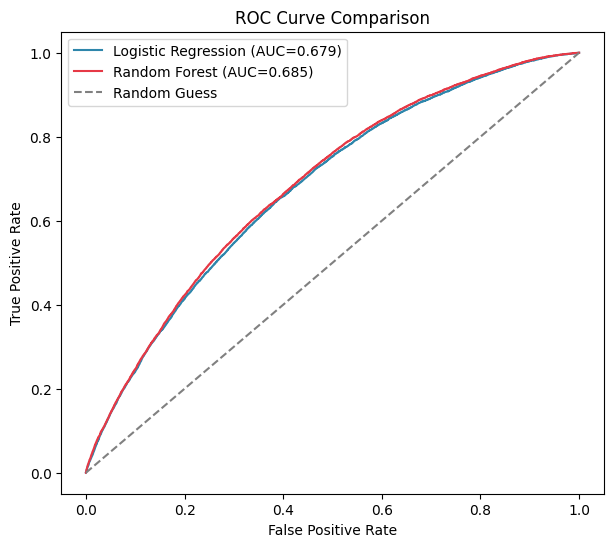

In [26]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', color='#2E86AB')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', color='#E63946')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

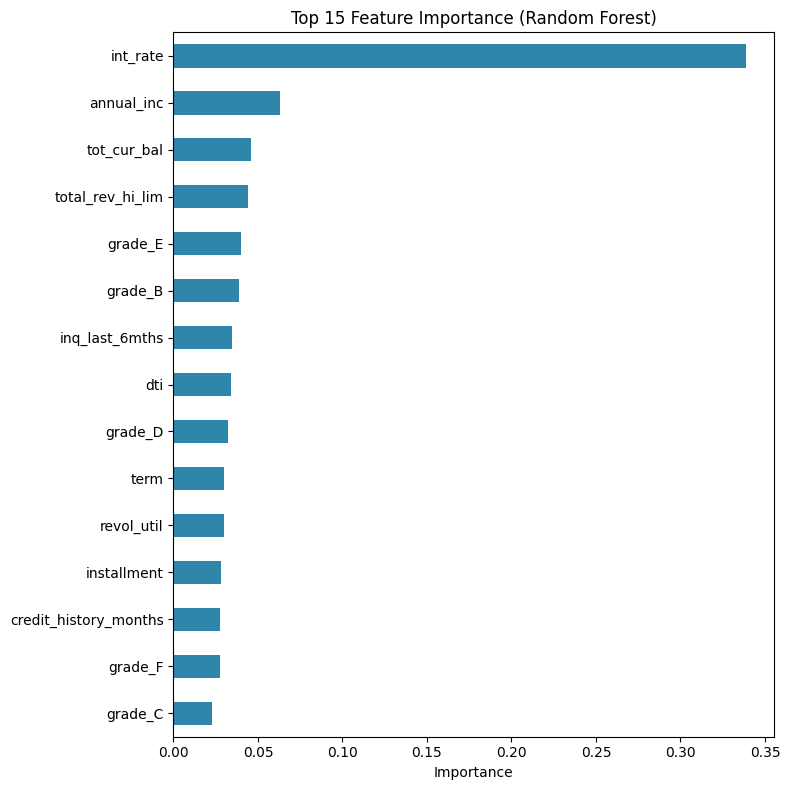

int_rate                 0.338528
annual_inc               0.062869
tot_cur_bal              0.045758
total_rev_hi_lim         0.044161
grade_E                  0.040240
grade_B                  0.038948
inq_last_6mths           0.034422
dti                      0.033765
grade_D                  0.032098
term                     0.030175
revol_util               0.029775
installment              0.028410
credit_history_months    0.027686
grade_F                  0.027602
grade_C                  0.022634
dtype: float64


In [27]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,8))
importances.head(15).plot(kind='barh', color='#2E86AB')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.head(15))

In [28]:
from xgboost import XGBClassifier
import time

# scale_pos_weight = rasio kelas mayoritas/minoritas, buat handle imbalance (mirip class_weight di RF/LR)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

start = time.time()
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train, y_train)
print("Waktu training:", round(time.time() - start, 2), "detik")

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("Selesai")

scale_pos_weight: 7.43
Waktu training: 15.36 detik
Selesai


In [29]:
print("=== Classification Report (XGBoost) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Good Loan', 'Bad Loan']))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# cek overfitting juga
xgb_train_auc = roc_auc_score(y_train, xgb.predict_proba(X_train)[:, 1])
print("\nTrain AUC:", round(xgb_train_auc, 4), "| Test AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

=== Classification Report (XGBoost) ===
              precision    recall  f1-score   support

   Good Loan       0.93      0.63      0.75     82186
    Bad Loan       0.19      0.66      0.30     11066

    accuracy                           0.63     93252
   macro avg       0.56      0.64      0.52     93252
weighted avg       0.84      0.63      0.70     93252

ROC-AUC: 0.6946

Confusion Matrix:
[[51508 30678]
 [ 3812  7254]]

Train AUC: 0.725 | Test AUC: 0.6946


                 Model  ROC-AUC  Recall (Bad Loan)  Precision (Bad Loan)
0  Logistic Regression   0.6790             0.6531                0.1829
1        Random Forest   0.6848             0.6352                0.1876
2              XGBoost   0.6946             0.6555                0.1912


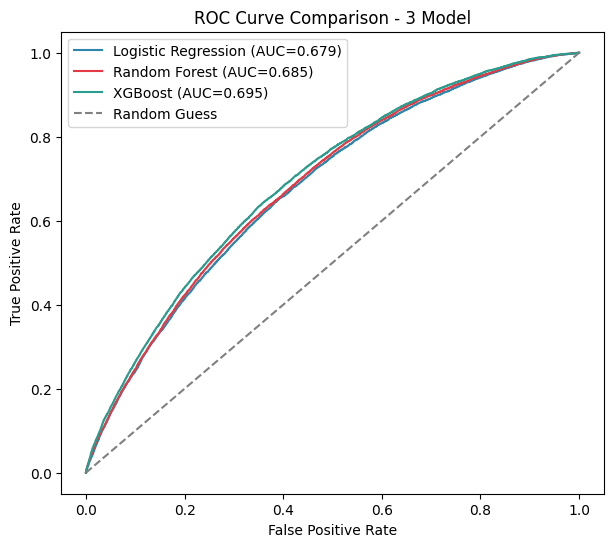

In [30]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'Recall (Bad Loan)': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']
    ],
    'Precision (Bad Loan)': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']
    ],
}).round(4)

print(summary)

# ROC curve gabungan
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', color='#2E86AB')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', color='#E63946')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})', color='#2A9D8F')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - 3 Model')
plt.legend()
plt.show()

## Kesimpulan

- Dari 3 model yang dicoba, **XGBoost** memberikan performa terbaik dengan ROC-AUC 0.695, diikuti Random Forest (0.685) dan Logistic Regression (0.679) sebagai baseline.
- Recall untuk bad loan (peminjam berisiko gagal bayar) berkisar 0.64-0.66 di ketiga model, artinya model cukup berhasil menangkap mayoritas peminjam berisiko, meski precision-nya masih rendah (~0.18-0.19) karena trade-off dari penanganan class imbalance.
- Fitur paling berpengaruh terhadap prediksi adalah **interest rate (int_rate)**, jauh di atas fitur lainnya. Ini masuk akal karena suku bunga yang ditetapkan lender kemungkinan sudah mencerminkan penilaian risiko awal terhadap peminjam.
- Random Forest dan XGBoost menunjukkan overfitting ringan (gap ROC-AUC train-test sekitar 0.03), sementara Logistic Regression paling stabil antara train dan test.
- Model ini masih bisa dikembangkan lebih lanjut, misalnya dengan hyperparameter tuning atau menambahkan fitur baru, untuk meningkatkan precision pada kelas bad loan.